# Build a model

Are the signals from `pbs-1`, `pbs-2`, and `pbs-3` sufficiently discrimatory of human breast cancer?


## 0. Initializations

In [1]:
## 0. Initializations
# -- imports --
import anndata as ad
import gseapy as gp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import seaborn as sns

import random

from collections import defaultdict

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.metrics import classification_report

from statistics import median

from sklearn.svm import LinearSVC

from signals_in_the_noise.analysis.noise_phenotypes import classify_noise_subtypes
from signals_in_the_noise.preprocessing.gse161529 import GSE161529

In [2]:
# -- datasets --
gse = GSE161529()

## 1. Preprocessing Data

1. Subset data to samples that have a potential biological signal.
2. Determine the distribution of number of samples per subject - use to downsample for parity.
3. Determine the distribution of number of cells per subject - use to downsample for parity

In [3]:
from signals_in_the_noise.analysis.noise_phenotypes import PbsThresholds, Thresholds

pbs_1_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=0.85, q_high=None, q_mod_low=None, q_mod_high=None),
    log1p_total_counts=Thresholds(q_low=None, q_high=0.3, q_mod_low=None, q_mod_high=None),
    log1p_n_genes_by_counts=Thresholds(q_low=None, q_high=0.3, q_mod_low=None, q_mod_high=None),
)
pbs_2_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=None, q_high=0.25, q_mod_low=None, q_mod_high=None),
    log1p_total_counts=Thresholds(q_low=None, q_high=0.3, q_mod_low=None, q_mod_high=None),
    log1p_n_genes_by_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.45, q_mod_high=0.85),
)
pbs_3_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=None, q_high=None, q_mod_low=0.3, q_mod_high=0.65),
    log1p_total_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.5, q_mod_high=0.85),
    log1p_n_genes_by_counts=Thresholds(q_low=0.95, q_high=None, q_mod_low=None, q_mod_high=None),
)
# pbs_1_thresholds = PbsThresholds(
#     pct_counts_mt=Thresholds(q_low=0.9, q_high=None, q_mod_low=None, q_mod_high=None),
#     log1p_total_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.1, q_mod_high=0.25),
#     log1p_n_genes_by_counts=Thresholds(q_low=None, q_high=0.25, q_mod_low=None, q_mod_high=None),
# )
# pbs_2_thresholds = PbsThresholds(
#     pct_counts_mt=Thresholds(q_low=None, q_high=0.15, q_mod_low=None, q_mod_high=None),
#     log1p_total_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.1, q_mod_high=0.25),
#     log1p_n_genes_by_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.40, q_mod_high=0.65),
# )
# pbs_3_thresholds = PbsThresholds(
#     pct_counts_mt=Thresholds(q_low=None, q_high=None, q_mod_low=0.25, q_mod_high=0.55),
#     log1p_total_counts=Thresholds(q_low=0.45, q_high=None, q_mod_low=None, q_mod_high=None),
#     log1p_n_genes_by_counts=Thresholds(q_low=0.7, q_high=None, q_mod_low=None, q_mod_high=None),
# )

In [4]:
# -- subset data --
subtype_to_adata = defaultdict(dict)
choices = ["pbs-1", "pbs-2", "pbs-3"]
for adata in gse.objects.values():
    if adata.uns['cell_population'] != 'Total':
        continue
    adata_noise = adata[adata.obs["is_noise"] == 1].copy()
    classify_noise_subtypes(adata_noise, pbs_thresholds={
        "pbs-1": pbs_1_thresholds,
        "pbs-2": pbs_2_thresholds,
        "pbs-3": pbs_3_thresholds,
})
#     classify_noise_subtypes(adata_noise)
    conditions = [
        adata_noise.obs["pbs-1"] == 1,
        adata_noise.obs["pbs-2"] == 1,
        adata_noise.obs["pbs-3"] == 1,
    ]
    adata_noise.obs["pbs"] = np.select(conditions, choices, default="none")
    adata_pbs_only = adata_noise[adata_noise.obs["pbs"] != "none"]
    subtype_to_adata[adata_pbs_only.uns['cancer_type']].update({
        adata_pbs_only.uns['title'] : adata_pbs_only
    })

In [5]:
subtype_to_adata.keys()

dict_keys(['Normal', 'BRCA1 pre-neoplastic', 'Triple negative tumour', 'Triple negative BRCA1 tumour', 'HER2+ tumour', 'PR+ tumour', 'ER+ tumour'])

In [6]:
def print_data_stats(adata_collection):
    results = []
    for subtype, adatas in adata_collection.items():
        num_subjects = len(adatas)
        num_samples = [adata.n_obs for adata in adatas.values()]
        print(f"{subtype} - {num_samples}")
        results.append((subtype, num_subjects, min(num_samples), median(num_samples)))
    
    return pd.DataFrame(results, columns=['Cancer sub-type', '# Subjects', 'Min # Samples', 'Median # Samples'])

print_data_stats(subtype_to_adata)

Normal - [33, 94, 460, 12, 22, 37, 6, 39, 47, 37, 34, 51, 147]
BRCA1 pre-neoplastic - [46, 47, 68, 67]
Triple negative tumour - [31, 52, 20, 61]
Triple negative BRCA1 tumour - [32, 54, 40, 132]
HER2+ tumour - [35, 139, 28, 4, 25, 505]
PR+ tumour - [15]
ER+ tumour - [125, 122, 113, 68, 14, 43, 118, 35, 22, 51, 53, 66, 81, 6, 202, 28, 358, 13]


,Cancer sub-type,# Subjects,Min # Samples,Median # Samples
0,Normal,13,6,37.0
1,BRCA1 pre-neoplastic,4,46,57.0
2,Triple negative tumour,4,20,41.5
3,Triple negative BRCA1 tumour,4,32,47.0
4,HER2+ tumour,6,4,31.5
5,PR+ tumour,1,15,15.0
6,ER+ tumour,18,6,59.5


### 1.a. Decisions

1. Exclude cancer sub-type `PR+ tumour` because there is only a single subject in the dataset.
2. Downsample subjects to `3` with a minimum of `50` samples.

### 1.b. Further subset data

Produces a dataset with the decisions.

In [7]:
def subset_data_for_modeling(require_min_subject=True, require_min_samples=True):
    results = {}
    for subtype, adatas in subtype_to_adata.items():
        if require_min_subject and subtype == 'PR+ tumour':
            # only has one subject, exclude
            continue
        valid_subjects_to_adata = defaultdict(dict)
        for adata in adatas.values():
            if require_min_samples and adata.n_obs < 50:
                # exclude subjects with fewer than 50 samples
                continue
            valid_subjects_to_adata.update({
                adata.uns['title']: adata,
            })
        results[subtype] = valid_subjects_to_adata
    return results
valid_adatas = subset_data_for_modeling()

In [8]:
print_data_stats(valid_adatas)

Normal - [94, 460, 51, 147]
BRCA1 pre-neoplastic - [68, 67]
Triple negative tumour - [52, 61]
Triple negative BRCA1 tumour - [54, 132]
HER2+ tumour - [139, 505]
ER+ tumour - [125, 122, 113, 68, 118, 51, 53, 66, 81, 202, 358]


,Cancer sub-type,# Subjects,Min # Samples,Median # Samples
0,Normal,4,51,120.5
1,BRCA1 pre-neoplastic,2,67,67.5
2,Triple negative tumour,2,52,56.5
3,Triple negative BRCA1 tumour,2,54,93.0
4,HER2+ tumour,2,139,322.0
5,ER+ tumour,11,51,113.0


### 1.3. Utility to Generate Dataset for Modeling

Creates a list of dataframe from the AnnDatas that represents all cancer sub-types (except for `PR+ tumour`), with the following characteristics:

1. `3` subjects per sub-type, `6` sub-types = `18` total subjects
2. `1` dataframe per subject
3. Columns
   1. `has_cancer`
   2. `cancer_type`
   3. `cell_population`
   4. `menopause_status`
   5. `pbs-1`
   6. `pbs-2`
   7. `pbs-3`

Separating the subjects to a row will simplify using the leave-one-out strategy.

In [9]:
def generate_dataframe_for_modeling(adata, *, downsample=True):
    results = []
    for adatas in adata.values():
        if downsample:
            subjects = np.random.choice(list(adatas.keys()), 3)
        else:
            subjects = adatas.keys()

        for subject in subjects:
            adata = adatas[subject]
            df = pd.DataFrame({
                'pbs-1': adata.obs['pbs-1'].astype(int),
                'pbs-2': adata.obs['pbs-2'].astype(int),
                'pbs-3': adata.obs['pbs-3'].astype(int),
            })
            df['has_cancer'] = (adata.uns['cancer_type'] != 'Normal')
            df['cancer_type'] = str(adata.uns['cancer_type'])
            df['cell_population'] = str(adata.uns['cell_population'])
            df['menopause_status'] = str(adata.uns['menopause_status'])
            
            results.append(df)
    return results

In [10]:
generate_dataframe_for_modeling(adata=valid_adatas)[0]

,pbs-1,pbs-2,pbs-3,has_cancer,cancer_type,cell_population,menopause_status
AAAGAACGTGACTAAA-1,0,1,0,False,Normal,Total,Post
AACAAAGAGGACTGGT-1,0,1,0,False,Normal,Total,Post
AACCCAAGTGCCTATA-1,0,1,0,False,Normal,Total,Post
AACGGGAGTGTCCGTG-1,0,1,0,False,Normal,Total,Post
AAGATAGTCGAGTACT-1,0,1,0,False,Normal,Total,Post
...,...,...,...,...,...,...,...
TTGAGTGTCATAGGCT-1,0,1,0,False,Normal,Total,Post
TTGCCTGAGACGGTCA-1,0,1,0,False,Normal,Total,Post
TTGGATGGTCGTGGTC-1,0,1,0,False,Normal,Total,Post
TTTCAGTGTATTCCTT-1,0,1,0,False,Normal,Total,Post


## 2. Build the classifier

In [11]:
def logistic_regression_loo_classifier(dfs, *, by_subjects=True, as_dict=False, model=None, target='cancer_type'):
    loo = LeaveOneOut()
    y_true, y_pred = [], []
    
    for train_idx, test_idx in loo.split(dfs):
        train_df = pd.concat([dfs[i] for i in train_idx])
        # there will only ever be one in the test
        test_df = dfs[test_idx[0]]
    
        X_train = train_df[['pbs-1', 'pbs-2', 'pbs-3']].values
        y_train = train_df[target].values
    
        X_test = test_df[['pbs-1', 'pbs-2', 'pbs-3']].values
        y_test = test_df[target].values

        if model is None:
            model = LogisticRegression(max_iter=1000)
        model.fit(X_train, y_train)
    
        if by_subjects:
            counts = np.unique(model.predict(X_test), return_counts=True)
            # return the majority vote for the subject
            y_pred.append(counts[0][np.argmax(counts[1])])
            y_true.append(test_df[target].iloc[0])
        else:
            y_pred.extend(model.predict(X_test))
            y_true.extend(y_test)
    
    return classification_report(y_true, y_pred, output_dict=as_dict)

### 2.1. Explore other models

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB
import warnings
from sklearn.exceptions import UndefinedMetricWarning

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=43,
        C=10,   # default is 1
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced',
        random_state=43,
        max_depth=5,    # default is None
        min_samples_leaf=20,    # default is 1
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=31,    # was 3 in other nbs
        weights='uniform',  # was distance in other nbs
        metric='hamming',   # default is minkowski
    ),
    'Naive Bayes': BernoulliNB(),
    'Random Forest': RandomForestClassifier(
        max_depth=5,
        min_samples_leaf=20,
        class_weight='balanced',
        random_state=43,
    ),
    'Linear SVC': LinearSVC(
        random_state=43,
        class_weight='balanced',
        C=10,
    ),
    'Ridge Classifier': RidgeClassifier(
        random_state=43,
        class_weight='balanced',
        alpha=0.5,
    )
}

### 2.2. Model ANY cancer

#### 2.3.1 Need to downsample to proceed

The data is not balanced in several ways:
- Subjects skew to having cancer
- Sample count per subject varies

To address this, build several models for different views that are more balanced:
- Normal vs Abnormal
  - Abnormal can be any combination of cancer subjects. For example, group cancer by comparable subject count.
- Subset subjects to get a balanced 

In [13]:
dfs = generate_dataframe_for_modeling(adata=valid_adatas, downsample=False)

In [14]:
dfs_cancer = []
dfs_normal = []

for df in dfs:
    if df['cancer_type'].unique()[0] == 'Normal':
        dfs_normal.append(df)
    else:
        dfs_cancer.append(df)

In [15]:
def get_balanced_dataset(minority_dfs, majority_dfs, num_minority_subjects=6):
    # select the normal subjects first, its the smaller number of total subjects
    some_minority = random.sample(minority_dfs, k=min(num_minority_subjects, len(minority_dfs)))
    # total number of cells (samples) to use for downsampling the abnormal (cancer) subjects
    num_minority_cells = sum([df.count().unique()[0] for df in some_minority])

    majority_pool = majority_dfs.copy()
    some_majority = []
    num_majority_cells = 0
    # iterate over cancer subjects
    for _ in majority_dfs:
        major = majority_pool.pop(random.randrange(len(majority_pool)))
        major_count = major.count().unique()[0]
        if major_count > num_minority_cells:
            continue
        some_majority.append(major)
        num_majority_cells += major_count
        if num_majority_cells >= num_minority_cells:
            break

    # print(num_majority_cells, num_minority_cells)
    return some_minority, some_majority
    
balanced_dfs_normal, balanced_dfs_cancer = get_balanced_dataset(dfs_normal, dfs_cancer)   

In [16]:
def report_has_cancer(minority, majority):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
        n_runs = 100
        model_avg_report = {}
        for model_name, model in models.items():
            reports = []
            for run in range(n_runs):
                _balanced_dfs_normal, _dfs = get_balanced_dataset(minority, majority)
                _dfs.extend(_balanced_dfs_normal)
                
                report = logistic_regression_loo_classifier(_dfs, by_subjects=False, as_dict=True, model=model, target="has_cancer")
                reports.append(pd.DataFrame(report).T)
        
            _avg_report = pd.concat(reports).groupby(level=0).mean()
        
            print(f"{'='*25}")
            print(f"Model: {model_name}")
            print(f"{'-'*25}")
            print(f"Mean: {_avg_report}")
            print()
            model_avg_report[model_name] = _avg_report
        return model_avg_report

report_has_cancer(dfs_normal, dfs_cancer)

Model: Logistic Regression
-------------------------
Mean:               precision    recall  f1-score      support
False          0.707753  0.812500  0.755348   752.000000
True           0.812173  0.706951  0.754506   884.850000
accuracy       0.756137  0.756137  0.756137     0.756137
macro avg      0.759963  0.759726  0.754927  1636.850000
weighted avg   0.765243  0.756137  0.755800  1636.850000

Model: Decision Tree
-------------------------
Mean:               precision    recall  f1-score      support
False          0.708278  0.812500  0.755354   752.000000
True           0.813978  0.709659  0.756509   892.270000
accuracy       0.757095  0.757095  0.757095     0.757095
macro avg      0.761128  0.761079  0.755931  1644.270000
weighted avg   0.766772  0.757095  0.756786  1644.270000

Model: KNN
-------------------------
Mean:               precision    recall  f1-score      support
False          0.000000  0.000000  0.000000   752.000000
True           0.537656  0.999531  0.698587  

{'Logistic Regression':               precision    recall  f1-score      support
 False          0.707753  0.812500  0.755348   752.000000
 True           0.812173  0.706951  0.754506   884.850000
 accuracy       0.756137  0.756137  0.756137     0.756137
 macro avg      0.759963  0.759726  0.754927  1636.850000
 weighted avg   0.765243  0.756137  0.755800  1636.850000,
 'Decision Tree':               precision    recall  f1-score      support
 False          0.708278  0.812500  0.755354   752.000000
 True           0.813978  0.709659  0.756509   892.270000
 accuracy       0.757095  0.757095  0.757095     0.757095
 macro avg      0.761128  0.761079  0.755931  1644.270000
 weighted avg   0.766772  0.757095  0.756786  1644.270000,
 'KNN':               precision    recall  f1-score      support
 False          0.000000  0.000000  0.000000   752.000000
 True           0.537656  0.999531  0.698587   884.350000
 accuracy       0.537538  0.537538  0.537538     0.537538
 macro avg      0.26882

In [17]:
def report_cancer_sub_types(minority, majority):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
        n_runs = 100
        model_avg_report = {}
        for model_name, model in models.items():
            reports = []
            for run in range(n_runs):
                _balanced_dfs_normal, _dfs = get_balanced_dataset(minority, majority)
                _dfs.extend(_balanced_dfs_normal)
                
                report = logistic_regression_loo_classifier(_dfs, by_subjects=False, as_dict=True, model=model)
                reports.append(pd.DataFrame(report).T)
        
            _avg_report = pd.concat(reports).groupby(level=0).mean()
        
            print(f"{'='*25}")
            print(f"Model: {model_name}")
            print(f"{'-'*25}")
            print(f"Mean: {_avg_report}")
            print()
            model_avg_report[model_name] = _avg_report
        return model_avg_report

report_cancer_sub_types(dfs_normal, dfs_cancer)

Model: Logistic Regression
-------------------------
Mean:                               precision    recall  f1-score      support
BRCA1 pre-neoplastic           0.040873  0.214675  0.068559    85.301887
ER+ tumour                     0.455381  0.258984  0.262028   467.150000
HER2+ tumour                   0.007883  0.000941  0.001681   370.015152
Normal                         0.342820  0.349867  0.337338   752.000000
Triple negative BRCA1 tumour   0.027811  0.038914  0.025298   110.095238
Triple negative tumour         0.120690  0.015105  0.026593    68.534483
accuracy                       0.262996  0.262996  0.262996     0.262996
macro avg                      0.223425  0.191305  0.170229  1617.680000
weighted avg                   0.331653  0.262996  0.255373  1617.680000

Model: Decision Tree
-------------------------
Mean:                               precision    recall  f1-score      support
BRCA1 pre-neoplastic           0.034607  0.143111  0.053370    79.740000
ER+ tumour 

{'Logistic Regression':                               precision    recall  f1-score      support
 BRCA1 pre-neoplastic           0.040873  0.214675  0.068559    85.301887
 ER+ tumour                     0.455381  0.258984  0.262028   467.150000
 HER2+ tumour                   0.007883  0.000941  0.001681   370.015152
 Normal                         0.342820  0.349867  0.337338   752.000000
 Triple negative BRCA1 tumour   0.027811  0.038914  0.025298   110.095238
 Triple negative tumour         0.120690  0.015105  0.026593    68.534483
 accuracy                       0.262996  0.262996  0.262996     0.262996
 macro avg                      0.223425  0.191305  0.170229  1617.680000
 weighted avg                   0.331653  0.262996  0.255373  1617.680000,
 'Decision Tree':                               precision    recall  f1-score      support
 BRCA1 pre-neoplastic           0.034607  0.143111  0.053370    79.740000
 ER+ tumour                     0.492267  0.342479  0.319340   492.9595

In [18]:
targets = ['ER+ tumour',]
dfs_target_cancer = [df for df in dfs_cancer if df['cancer_type'].unique()[0] in targets]
avg_reports = report_cancer_sub_types(dfs_normal, dfs_target_cancer)

Model: Logistic Regression
-------------------------
Mean:               precision    recall  f1-score      support
ER+ tumour     0.826682  0.802355  0.814061   847.000000
Normal         0.786786  0.812500  0.799116   752.000000
accuracy       0.807303  0.807303  0.807303     0.807303
macro avg      0.806734  0.807428  0.806589  1599.000000
weighted avg   0.808506  0.807303  0.807417  1599.000000

Model: Decision Tree
-------------------------
Mean:               precision    recall  f1-score      support
ER+ tumour     0.830154  0.804322  0.816751   867.280000
Normal         0.784369  0.812500  0.797830   752.000000
accuracy       0.808233  0.808233  0.808233     0.808233
macro avg      0.807262  0.808411  0.807290  1619.280000
weighted avg   0.809690  0.808233  0.808425  1619.280000

Model: KNN
-------------------------
Mean:               precision    recall  f1-score      support
ER+ tumour     0.527501  1.000000  0.690390   843.370000
Normal         0.000000  0.000000  0.000000  

In [19]:
# targets = ['HER2+ tumour', 'Triple negative tumour', 'Triple negative BRCA1 tumour']
# dfs_target_cancer = [df for df in dfs_cancer if df['cancer_type'].unique()[0] in targets]
# report_has_cancer(dfs_target_cancer, dfs_normal)

In [20]:
# targets = ['Triple negative tumour', 'Triple negative BRCA1 tumour']
# dfs_target_cancer = [df for df in dfs_cancer if df['cancer_type'].unique()[0] in targets]
# report_has_cancer(dfs_target_cancer, dfs_normal)

In [21]:
# targets = ['HER2+ tumour']
# dfs_target_cancer = [df for df in dfs_cancer if df['cancer_type'].unique()[0] in targets]
# report_has_cancer(dfs_target_cancer, dfs_normal)

In [22]:
# targets = ['BRCA1 pre-neoplastic']
# dfs_target_cancer = [df for df in dfs_cancer if df['cancer_type'].unique()[0] in targets]
# report_has_cancer(dfs_target_cancer, dfs_normal)

In [23]:
def figure_for_poster(avg_report, minority_label="True", majority_label="False", small=False):
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    import numpy as np
    
    # ── DATA from avg_report ─────────────────────────────────────────────────────
    support_false   = avg_report.loc[majority_label,     "support"]
    support_true    = avg_report.loc[minority_label,      "support"]
    recall_false    = avg_report.loc[majority_label,     "recall"]
    recall_true     = avg_report.loc[minority_label,      "recall"]
    precision_false = avg_report.loc[majority_label,     "precision"]
    precision_true  = avg_report.loc[minority_label,      "precision"]
    f1_false        = avg_report.loc[majority_label,     "f1-score"]
    f1_true         = avg_report.loc[minority_label,      "f1-score"]
    accuracy        = avg_report.loc["accuracy",  "f1-score"]
    macro_f1        = avg_report.loc["macro avg", "f1-score"]
    
    tn = round(support_false * recall_false)
    fp = round(support_false * (1 - recall_false))
    fn = round(support_true  * (1 - recall_true))
    tp = round(support_true  * recall_true)
    
    cm      = np.array([[tn, fp], [fn, tp]])
    support = [support_false, support_true]
    blue    = "#0072B2"
    orange  = "#D55E00"
    
    # ── FIGURE ───────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(8, 5))
    
    ax_cm     = fig.add_axes([0.05, 0.10, 0.50, 0.80])

    if small:
        font_sizes = [26, 20, 20]
    else:
        font_sizes = [32, 26, 20]
    
    # ── CONFUSION MATRIX ─────────────────────────────────────────────────────────
    if small:
        classes = [f"{minority_label}", f"{majority_label}"]
    else:
        classes = [f"{minority_label}\n(no cancer)", f"{majority_label}\n(cancer)"]
    
    for i in range(2):
        for j in range(2):
            val = cm[i, j]
            pct = val / support[i] if support[i] > 0 else 0
     
            if i == j:
                color = blue
                alpha = 0.15 + pct * 0.75
            else:
                color = orange
                alpha = 0.10 + pct * 0.70

            if small:
                rect = patches.FancyBboxPatch(
                    (j + 0.08, 1 - i + 0.08), 0.84, 0.84,
                    boxstyle="round,pad=0.02",
                    facecolor=color, alpha=max(alpha, 0.08),
                    linewidth=0
                )
            else:
                rect = patches.FancyBboxPatch(
                    (j + 0.04, 1 - i + 0.04), 0.92, 0.92,
                    boxstyle="round,pad=0.02",
                    facecolor=color, alpha=max(alpha, 0.08),
                    linewidth=0
                )
            ax_cm.add_patch(rect)
     
            text_color = "#00274C"
            if small:
                ax_cm.text(j + 0.5, 1 - i + 0.60, f"{int(val):,}",
                           ha="center", va="center",
                           fontsize=font_sizes[0], fontweight="500", color=text_color)
                ax_cm.text(j + 0.5, 1 - i + 0.35, f"{pct:.1%}",
                           ha="center", va="center",
                           fontsize=font_sizes[1], color=text_color, alpha=0.85)
            else:
                ax_cm.text(j + 0.5, 1 - i + 0.60, f"{int(val):,}",
                           ha="center", va="center",
                           fontsize=font_sizes[0], fontweight="500", color=text_color)
                ax_cm.text(j + 0.5, 1 - i + 0.28, f"{pct:.1%}",
                           ha="center", va="center",
                           fontsize=font_sizes[1], color=text_color, alpha=0.85)
     
    ax_cm.set_xticks([0.5, 1.5])
    ax_cm.set_xticklabels(classes, fontsize=font_sizes[2], color="#00274C")
    ax_cm.set_yticks([0.5, 1.5])
    ax_cm.set_yticklabels(classes[::-1], fontsize=font_sizes[2])
    ax_cm.set_xlim(0, 2)
    ax_cm.set_ylim(0, 2)
    ax_cm.set_xlabel("predicted label", fontsize=font_sizes[2])
    ax_cm.set_ylabel("true label", fontsize=font_sizes[2])
    ax_cm.spines[:].set_visible(False)
    ax_cm.tick_params(length=0)
    
    # from matplotlib.patches import Patch
    # legend_elements = [
    #     Patch(facecolor=blue,   alpha=0.8, label="correct"),
    #     Patch(facecolor=orange, alpha=0.8, label="misclassified"),
    # ]
    # ax_metric.legend(handles=legend_elements,
    #                  loc="lower right",
    #                  bbox_to_anchor=(1, -0.01),
    #                  frameon=False, fontsize=8,
    #                  ncol=1, handlelength=1)
    
    # ── METRICS PANEL ────────────────────────────────────────────────────────────
    # ax_metric.axis("off")
    
    # ax_metric.text(0, 1.00, "accuracy",       transform=ax_metric.transAxes,
    #                fontsize=9, color="gray")
    # ax_metric.text(0, 0.92, f"{accuracy:.1%}", transform=ax_metric.transAxes,
    #                fontsize=20, fontweight="500")
    # ax_metric.text(0, 0.82, "macro F1",       transform=ax_metric.transAxes,
    #                fontsize=9, color="gray")
    # ax_metric.text(0, 0.74, f"{macro_f1:.3f}", transform=ax_metric.transAxes,
    #                fontsize=20, fontweight="500")
    
    # ax_metric.axhline(y=0.70, xmin=0, xmax=1,
    #                   color="#CCCCCC", linewidth=0.5)
    
    # ax_metric.text(0, 0.66, "recall / F1 by class", transform=ax_metric.transAxes,
    #                fontsize=9, color="gray")
    
    # metrics = [
    #     ("no cancer recall", recall_false, blue),
    #     ("cancer recall",    recall_true,  orange),
    #     ("no cancer F1",     f1_false,     blue),
    #     ("cancer F1",        f1_true,      orange),
    # ]
    
    # bar_y = [0.58, 0.46, 0.31, 0.19]
    
    # for (label, val, color), y in zip(metrics, bar_y):
    #     ax_metric.text(0, y + 0.02, label, transform=ax_metric.transAxes,
    #                    fontsize=8, color="white")
    #     ax_metric.text(1, y + 0.02, f"{val*100:.2f}%", transform=ax_metric.transAxes,
    #                    fontsize=8, color="black", ha="right")
    #     ax_metric.add_patch(patches.FancyBboxPatch(
    #         (0, y), 1, 0.06,
    #         boxstyle="round,pad=0.005",
    #         transform=ax_metric.transAxes,
    #         facecolor="#EEEEEE", linewidth=0, clip_on=False
    #     ))
    #     if val > 0.001:
    #         ax_metric.add_patch(patches.FancyBboxPatch(
    #             (0, y), val, 0.06,
    #             boxstyle="round,pad=0.005",
    #             transform=ax_metric.transAxes,
    #             facecolor=color, alpha=0.8, linewidth=0, clip_on=False
    #         ))
    
    # ax_metric.axhline(y=0.14, xmin=0, xmax=1,
    #                   color="#CCCCCC", linewidth=0.5)
    
    # ax_metric.text(0, 0.08, f"no cancer  n={int(support_false):,}",
    #                transform=ax_metric.transAxes, fontsize=8, color="gray")
    # ax_metric.text(0, 0.00, f"cancer     n={int(support_true):,}",
    #                transform=ax_metric.transAxes, fontsize=8, color="gray")
    
    # plt.suptitle("Decision Tree — mean classification report", fontsize=11, y=0.97)
    plt.rcParams.update({
        'axes.labelcolor': "#00274C",
        'text.color': "#00274C",
        'xtick.labelcolor': "#00274C",
        'ytick.labelcolor': "#00274C",
    })
    if small:
        plt.savefig("../images/iscb-scs-postcard.png", dpi=300, bbox_inches="tight", transparent=True)
    else:
        plt.savefig("../images/iscb-scs-figure-4.png", dpi=300, bbox_inches="tight", transparent=True)
    plt.show()

In [24]:
avg_report = avg_reports['Random Forest']

In [25]:
avg_report

,precision,recall,f1-score,support
ER+ tumour,0.826682,0.802355,0.814061,847.000000
Normal,0.786786,0.812500,0.799116,752.000000
accuracy,0.807303,0.807303,0.807303,0.807303
macro avg,0.806734,0.807428,0.806589,1599.000000
weighted avg,0.808506,0.807303,0.807417,1599.000000


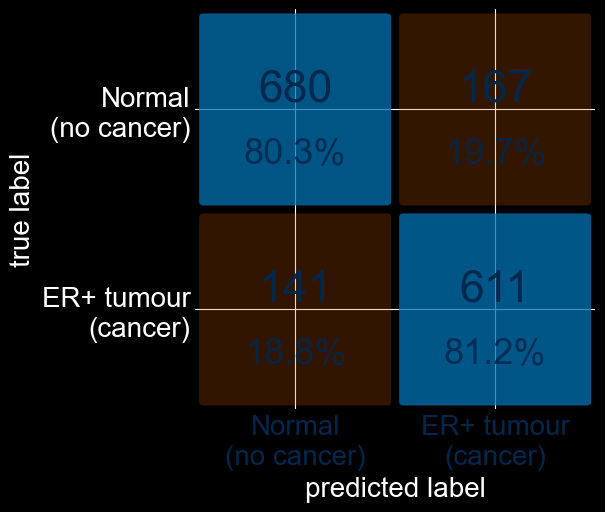

In [26]:
figure_for_poster(avg_report, "Normal", "ER+ tumour")

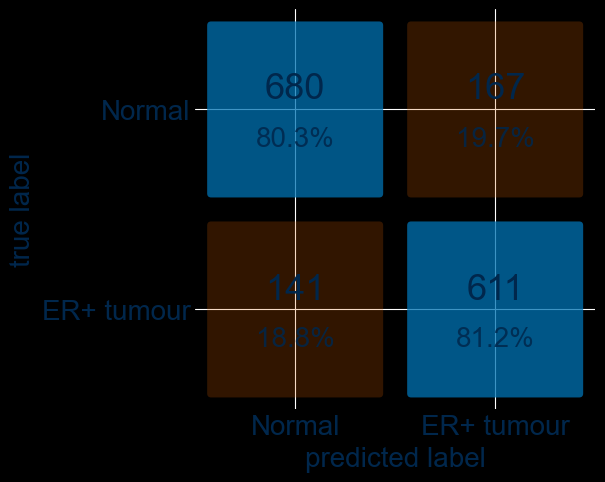

In [27]:
figure_for_poster(avg_report, "Normal", "ER+ tumour", small=True)